# LightGBM による時系列予測

強力な機械学習アルゴリズムである `LightGBM` を使用します。
時系列データを機械学習で扱うための「特徴量エンジニアリング」、学習プロセスの可視化（学習曲線・特徴量重要度）、そして「再帰的予測（Recursive Forecasting）」を実装しています。

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.extract import extract_data
from src.transfform import transform_data

plt.style.use("seaborn-v0_8-whitegrid")

raw_path = Path("data/raw/data.csv")
df = transform_data(extract_data(raw_path))

series = (
    df.set_index("date")["temp_avg"]
    .asfreq("D")
    .astype(float)
    .interpolate(method="time")
)


抽出後のカラム:
['年月日', '平均気温(℃)', '最高気温(℃)', '最低気温(℃)']
変換後のデータの最初の3行は
        年月日 平均気温(℃)       date  temp_avg
0  2025/1/1     5.9 2025-01-01       5.9
1  2025/1/2     6.2 2025-01-02       6.2
2  2025/1/3     6.4 2025-01-03       6.4


In [2]:
# 特徴量エンジニアリング（機械学習用の入力データ作り）
# LightGBMは時系列特有の「波」や「順番」をそのままでは理解できないため、
# 日付情報（月、何日目か）や、「過去の気温（ラグ）」を新しい列（特徴量）として作ります。

def create_features(series):
    df_feat = pd.DataFrame({"temp_avg": series})
    df_feat["dayofyear"] = df_feat.index.dayofyear
    df_feat["month"] = df_feat.index.month
    df_feat["trend"] = np.arange(len(df_feat))
    
    # 過去1日〜7日前の気温（ラグ特徴量）
    for i in range(1, 8):
        df_feat[f"lag_{i}"] = df_feat["temp_avg"].shift(i)
        
    # 過去7日間の移動平均
    df_feat["rolling_mean_7"] = df_feat["temp_avg"].shift(1).rolling(window=7).mean()
    
    return df_feat

df_features = create_features(series)
# ラグ(過去のデータ)を作ったため、最初の7日間は「過去データが存在しない」状態になります（NaN）。
# 学習エラーを防ぐため、NaNを含む行を削除します。
df_features = df_features.dropna() 

# データの分割 (最後の30日をテスト、それ以前を学習に)
train_size = len(df_features) - 30
train = df_features.iloc[:train_size]
test = df_features.iloc[train_size:]

X_train = train.drop(columns=["temp_avg"])
y_train = train["temp_avg"]
X_test = test.drop(columns=["temp_avg"])
y_test = test["temp_avg"]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (328, 11), Test: (30, 11)


In [3]:
# LightGBMモデルの学習と学習プロセスの記録
model = lgb.LGBMRegressor(
    n_estimators=300,        # 決定木を最大何本作るか
    learning_rate=0.05,      # 学習率（小さいほど慎重に学習する）
    random_state=42,
    importance_type="gain"   # 特徴量重要度の計算方法
)

# 学習の進み具合（誤差の減り方）を記録する辞書
evals_result = {}

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], # 学習データと検証用（テスト）データを渡す
    eval_names=["train", "valid"],
    callbacks=[
        lgb.log_evaluation(50),               # 50回ごとにログを出力
        lgb.record_evaluation(evals_result),  # 評価結果を保存
        lgb.early_stopping(stopping_rounds=50) # 50回連続で精度が改善しなかったら学習を打ち切る（過学習防止）
    ]
)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 981
[LightGBM] [Info] Number of data points in the train set: 328, number of used features: 11
[LightGBM] [Info] Start training from score 18.678659
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


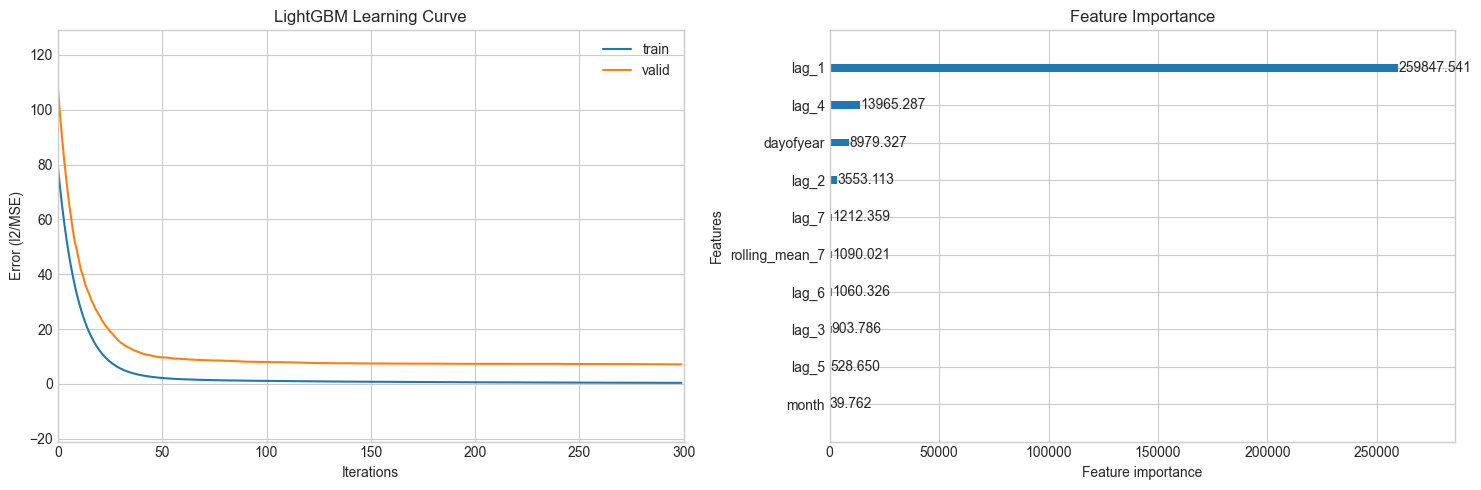

In [4]:
# 学習プロセスの可視化
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 学習曲線（Learning Curve）
# 木（学習回数）が増えるごとに、誤差がどう減っていったかを確認します
lgb.plot_metric(evals_result, metric="l2", ax=axes[0])
axes[0].set_title("LightGBM Learning Curve")
axes[0].set_ylabel("Error (l2/MSE)")

# 2. 特徴量重要度（Feature Importance）
# どのデータが予測に一番役立ったかを可視化します
lgb.plot_importance(model, max_num_features=10, ax=axes[1], importance_type="gain")
axes[1].set_title("Feature Importance")

plt.tight_layout()
plt.show()


LightGBM -> MAE=4.000, RMSE=4.489


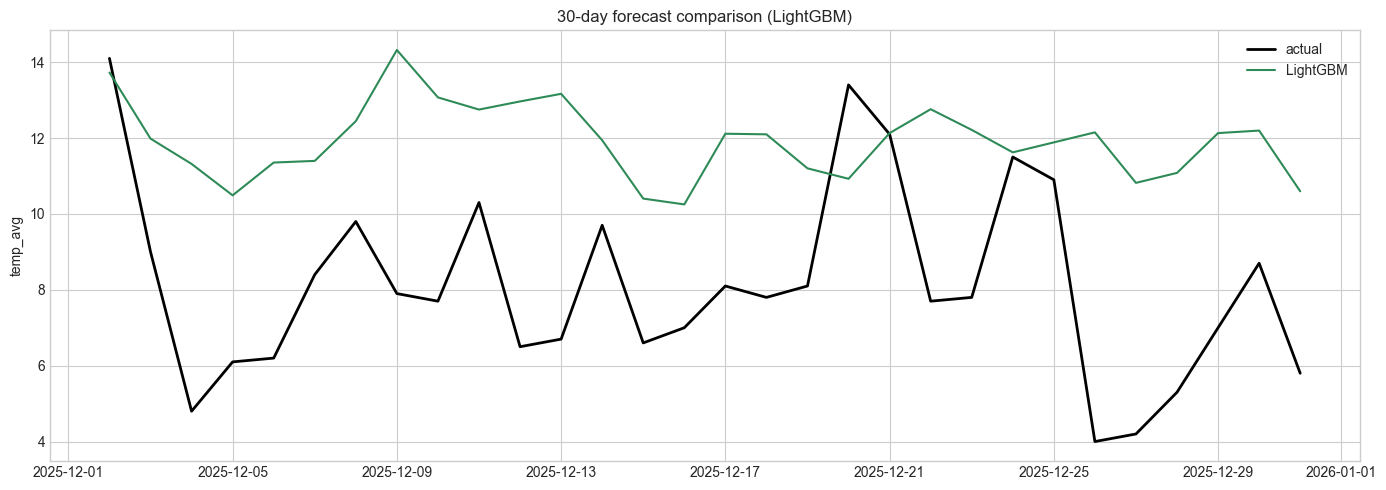

In [5]:
# 再帰的予測（Recursive Forecasting）
# 30日先を予測するため、「1日目を予測する」→「その予測値を『昨日の気温(lag_1)』として使って2日目を予測する」
# というステップを30回繰り返します。

# これまでの気温実績のリスト（順次ここに予測値を追加していく）
history = list(y_train.values)
predictions = []

test_dates = X_test.index
test_trends = X_test["trend"].values
test_dayofyears = X_test["dayofyear"].values
test_months = X_test["month"].values

for i in range(len(test)):
    # 最新の履歴から、予測する日のための特徴量を計算
    current_features = {
        "dayofyear": test_dayofyears[i],
        "month": test_months[i],
        "trend": test_trends[i],
    }
    
    # historyの後ろから1個目、2個目...を取り出してラグ特徴量にする
    for lag in range(1, 8):
        current_features[f"lag_{lag}"] = history[-lag]
        
    # 直近7日間の移動平均
    current_features["rolling_mean_7"] = np.mean(history[-7:])
    
    # データフレームに変換し、学習時と同じ列順に並べる
    df_curr = pd.DataFrame([current_features])
    df_curr = df_curr[X_train.columns]
    
    # 1日分だけ予測
    pred = model.predict(df_curr)[0]
    predictions.append(pred)
    
    # 次の日の予測のために、予測した値を履歴に追加する
    history.append(pred)

def score(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

lgb_mae, lgb_rmse = score(y_test, predictions)
print(f"LightGBM -> MAE={lgb_mae:.3f}, RMSE={lgb_rmse:.3f}")

# プロット
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, y_test, label="actual", color="black", linewidth=2)
ax.plot(test_dates, predictions, label="LightGBM", color="seagreen")
ax.set_title("30-day forecast comparison (LightGBM)")
ax.set_ylabel("temp_avg")
ax.legend()
plt.tight_layout()
plt.show()
